## **Video Prediction**

### Imports

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [3]:
import torch
from torchvision import transforms
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
from src.model import WaterQualityResNet18

### Model Loading

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = WaterQualityResNet18(num_classes=3, pretrained=True, freeze_backbone=False)
model.load_state_dict(torch.load('../artifacts/best_model.pth', map_location=device))
model = model.to(device)
model.eval()

class_names = ['clean', 'muddy', 'polluted']

#### Frame Extraction from Video

In [8]:
def extract_frames(video_path, resize=(224,224)):
    frames = []
    cap = cv2.VideoCapture(video_path)

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, resize)
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

    cap.release()
    return frames

### Frame Prediction and Majority Class

In [17]:
def predict_video(video_path):
    frames = extract_frames(video_path)
    transform = transforms.ToTensor()

    frame_preds = []
    frame_confidences = []

    for frame in frames:
        img = Image.fromarray(frame)
        img_tensor = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(img_tensor)
            probabilities = torch.softmax(output, dim=1)
            conf, pred = torch.max(probabilities, 1)

        frame_preds.append(pred.item())
        frame_confidences.append(conf.item())

    # Majority vote for class
    pred_class = max(set(frame_preds), key=frame_preds.count)
    avg_confidence = sum(frame_confidences) / len(frame_confidences)

    plt.figure(figsize=(8, 6))
    plt.imshow(frames[-1])
    plt.axis("off")
    plt.title(f"Video Prediction: {class_names[pred_class]} (Avg conf: {avg_confidence * 100:.2f}%)")
    plt.show()

    print(f"Predicted Class: {class_names[pred_class]}")
    print(f"Average Confidence: {avg_confidence*100:.2f}%")


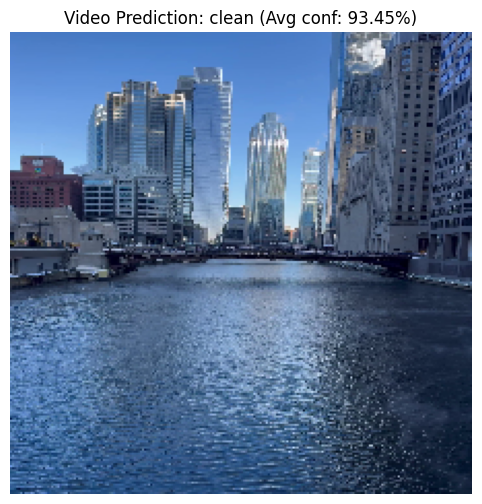

Predicted Class: clean
Average Confidence: 93.45%


In [18]:
predict_video("../data/clean_vdo2.mp4")